<a href="https://colab.research.google.com/github/srilakshmi-saladi/unet/blob/main/skinds_vit_76.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q timm opencv-python

import os, gc, glob, random, shutil, time, warnings, math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, f1_score, accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
import timm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 56.5 MB/s eta 0:00:00
Device: cpu


In [5]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/Dermo dataset /archive')
META_CSV = BASE_DIR / 'HAM10000_metadata.csv'
IMG_DIR1 = BASE_DIR / 'HAM10000_images_part_1'
IMG_DIR2 = BASE_DIR / 'HAM10000_images_part_2'

print("Metadata:", META_CSV.exists())
print("Part1:", IMG_DIR1.exists())
print("Part2:", IMG_DIR2.exists())


Mounted at /content/drive
Metadata: True
Part1: True
Part2: True


In [6]:
LOCAL_IMG_DIR = Path('/content/ham_images')
LOCAL_IMG_DIR.mkdir(exist_ok=True)

already_copied = len(list(LOCAL_IMG_DIR.glob('*.jpg')))
print(f'Already copied: {already_copied} images')

if already_copied < 10000:
    print('Copying images from Drive to local SSD...')
    start = time.time()
    for src_dir in [IMG_DIR1, IMG_DIR2]:
        for img_path in tqdm(list(src_dir.glob('*.jpg')), desc=src_dir.name):
            dst = LOCAL_IMG_DIR / img_path.name
            if not dst.exists():
                shutil.copy2(img_path, dst)
    print(f"Done in {(time.time()-start)/60:.1f} minutes.")
else:
    print("Images already copied.")

Already copied: 0 images
Copying images from Drive to local SSD...


HAM10000_images_part_2: 100%|██████████| 5015/5015 [03:44<00:00, 22.35it/s]

Done in 7.5 minutes.


In [7]:
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS2IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

df = pd.read_csv(META_CSV)

def find_local_image(image_id):
    p = LOCAL_IMG_DIR / f'{image_id}.jpg'
    return str(p) if p.exists() else None

df['path'] = df['image_id'].apply(find_local_image)
df['label'] = df['dx'].map(CLASS2IDX)
df = df.dropna(subset=['path', 'label']).reset_index(drop=True)

print("Total images:", len(df))
print(df['dx'].value_counts())

Total images: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [8]:
USE_LESION_CROP = True
LOCAL_CROP_DIR = Path('/content/ham_crops')
LOCAL_CROP_DIR.mkdir(exist_ok=True)

def simple_lesion_crop(img_bgr, pad=20):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    coords = cv2.findNonZero(mask)
    if coords is None:
        return img_bgr

    x, y, w, h = cv2.boundingRect(coords)
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(img_bgr.shape[1], x + w + pad)
    y2 = min(img_bgr.shape[0], y + h + pad)

    cropped = img_bgr[y1:y2, x1:x2]
    if cropped.size == 0:
        return img_bgr
    return cropped

def ensure_crop(path):
    fname = os.path.basename(path)
    out_path = LOCAL_CROP_DIR / fname
    if out_path.exists():
        return str(out_path)

    img = cv2.imread(path)
    if img is None:
        return path

    cropped = simple_lesion_crop(img, pad=20)
    cv2.imwrite(str(out_path), cropped)
    return str(out_path)

if USE_LESION_CROP:
    print("Creating lesion-focused crops...")
    df['model_path'] = df['path'].apply(ensure_crop)
else:
    df['model_path'] = df['path']

df[['image_id', 'dx', 'path', 'model_path']].head()

Creating lesion-focused crops...


,image_id,dx,path,model_path
0,ISIC_0027419,bkl,/content/ham_images/ISIC_0027419.jpg,/content/ham_crops/ISIC_0027419.jpg
1,ISIC_0025030,bkl,/content/ham_images/ISIC_0025030.jpg,/content/ham_crops/ISIC_0025030.jpg
2,ISIC_0026769,bkl,/content/ham_images/ISIC_0026769.jpg,/content/ham_crops/ISIC_0026769.jpg
3,ISIC_0025661,bkl,/content/ham_images/ISIC_0025661.jpg,/content/ham_crops/ISIC_0025661.jpg
4,ISIC_0031633,bkl,/content/ham_images/ISIC_0031633.jpg,/content/ham_crops/ISIC_0031633.jpg


In [9]:
lesion_df = df.groupby('lesion_id')['dx'].agg(lambda x: x.mode()[0]).reset_index()
lesion_df.columns = ['lesion_id', 'dx_majority']

train_lesions, temp_lesions = train_test_split(
    lesion_df['lesion_id'],
    test_size=0.25,
    stratify=lesion_df['dx_majority'],
    random_state=SEED
)

temp_lesions_df = lesion_df[lesion_df['lesion_id'].isin(temp_lesions)]

val_lesions, test_lesions = train_test_split(
    temp_lesions_df['lesion_id'],
    test_size=0.5,
    stratify=temp_lesions_df['dx_majority'],
    random_state=SEED
)

train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
val_df   = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df['dx'].value_counts())

Train: 7506 | Val: 1246 | Test: 1263
dx
nv       5027
mel       833
bkl       832
bcc       386
akiec     241
vasc      108
df         79
Name: count, dtype: int64


In [10]:
counts = np.array([len(train_df[train_df['label'] == i]) for i in range(NUM_CLASSES)], dtype=float)
class_weights = (1.0 / counts)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print({n: round(w, 2) for n, w in zip(CLASS_NAMES, class_weights)})

{'akiec': np.float64(0.93), 'bcc': np.float64(0.58), 'bkl': np.float64(0.27), 'df': np.float64(2.83), 'mel': np.float64(0.27), 'nv': np.float64(0.04), 'vasc': np.float64(2.07)}


In [11]:
IMG_SIZE = 224
BATCH_SIZE = 16   # if OOM, reduce to 8

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def get_transforms(img_size, mode='train'):
    if mode == 'train':
        return T.Compose([
            T.Resize((img_size + 16, img_size + 16)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.RandomRotation(12),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['model_path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

def make_loaders(img_size, batch_size=16):
    kw = dict(num_workers=0, pin_memory=True)

    train_loader = DataLoader(
        SkinDataset(train_df, get_transforms(img_size, 'train')),
        batch_size=batch_size, shuffle=True, drop_last=True, **kw
    )
    val_loader = DataLoader(
        SkinDataset(val_df, get_transforms(img_size, 'val')),
        batch_size=batch_size, shuffle=False, **kw
    )
    test_loader = DataLoader(
        SkinDataset(test_df, get_transforms(img_size, 'test')),
        batch_size=batch_size, shuffle=False, **kw
    )
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(IMG_SIZE, BATCH_SIZE)
print("Loaders ready.")

Loaders ready.


In [12]:
# Strongest single-model direction to try first
# If OOM, switch to vit_base_patch16_224
MODEL_NAME = 'vit_large_patch16_224'

def build_vit(num_classes=7):
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.2
    )

    # Warm-up stage: train head only
    for name, p in model.named_parameters():
        p.requires_grad = ('head' in name)

    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{MODEL_NAME} — trainable params (head only): {n:,}")
    return model

vit_model = build_vit(NUM_CLASSES).to(DEVICE)

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

vit_large_patch16_224 — trainable params (head only): 7,175


In [13]:
def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_loss(criterion, out, ya, yb, lam):
    return lam * criterion(out.float(), ya) + (1-lam) * criterion(out.float(), yb)

def train_epoch(model, loader, optimizer, criterion, scaler, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, leave=False, desc='Train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with autocast():
            if use_mixup and random.random() < 0.5:
                imgs, ya, yb, lam = mixup_data(imgs, labels)
                out = model(imgs)
                loss = mixup_loss(criterion, out, ya, yb, lam)
            else:
                out = model(imgs)
                loss = criterion(out.float(), labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion_eval = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    total = 0

    for imgs, labels in tqdm(loader, leave=False, desc='Val/Test'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        with autocast():
            out = model(imgs)

        loss = criterion_eval(out.float(), labels)
        probs = F.softmax(out, dim=1)

        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        total += imgs.size(0)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    return total_loss / total, acc, f1, qwk, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [14]:
def train_model(model, name, train_loader, val_loader, epochs=12, lr=1e-3):
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR, label_smoothing=0.1)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    scaler = GradScaler()

    best_f1 = -1
    best_state = None
    patience = 6
    wait = 0

    history = []

    print(f"\nTraining {name}")
    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, scaler, use_mixup=True)
        vl, va, vf1, vqwk, _, _, _ = evaluate(model, val_loader)
        scheduler.step()

        history.append([ep, tl, ta, vl, va, vf1, vqwk])
        print(f"Ep {ep:02d}/{epochs} | train loss={tl:.4f} acc={ta:.4f} | val loss={vl:.4f} acc={va:.4f} f1={vf1:.4f} qwk={vqwk:.4f}")

        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history, columns=['epoch','train_loss','train_acc','val_loss','val_acc','val_f1','val_qwk'])

vit_model, hist_stage1 = train_model(
    vit_model, "ViT_L16_Stage1", train_loader, val_loader, epochs=12, lr=1e-3
)

torch.save(vit_model.state_dict(), "/content/vit_stage1_best.pth")
hist_stage1.tail()


Training ViT_L16_Stage1


Ep 01/12 | train loss=3.0481 acc=0.2400 | val loss=1.9561 acc=0.1830 f1=0.2490 qwk=0.2819


Ep 02/12 | train loss=2.7752 acc=0.2701 | val loss=2.3957 acc=0.1228 f1=0.2222 qwk=0.4646


Ep 03/12 | train loss=2.7124 acc=0.2783 | val loss=1.4952 acc=0.4205 f1=0.3268 qwk=0.3845


Ep 04/12 | train loss=2.6413 acc=0.2826 | val loss=1.3701 acc=0.4599 f1=0.4013 qwk=0.5919


...

Ep 07/12 | train loss=2.4426 acc=0.2957 | val loss=1.7866 acc=0.1782 f1=0.2718 qwk=0.3010


Ep 08/12 | train loss=2.3960 acc=0.3050 | val loss=1.5578 acc=0.3242 f1=0.3279 qwk=0.4191


Ep 09/12 | train loss=2.3587 acc=0.3061 | val loss=1.5557 acc=0.3395 f1=0.3349 qwk=0.4386


Ep 10/12 | train loss=2.3367 acc=0.3032 | val loss=1.5192 acc=0.3387 f1=0.3540 qwk=0.4061
Early stopping triggered.


,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_qwk
5,6,2.511485,0.284915,1.653024,0.337881,0.318181,0.420934
6,7,2.442616,0.295709,1.786552,0.178170,0.271781,0.301001
7,8,2.396038,0.305037,1.557800,0.324238,0.327865,0.419100
8,9,2.358699,0.306103,1.555704,0.339486,0.334863,0.438635
9,10,2.336692,0.303172,1.519201,0.338684,0.353999,0.406127


In [15]:
vit_model.load_state_dict(torch.load("/content/vit_stage1_best.pth", map_location=DEVICE))

for p in vit_model.parameters():
    p.requires_grad = True

# Small LR for full fine-tuning
vit_model, hist_stage2 = train_model(
    vit_model, "ViT_L16_Stage2_FT", train_loader, val_loader, epochs=10, lr=2e-5
)

torch.save(vit_model.state_dict(), "/content/vit_stage2_best.pth")
hist_stage2.tail()


Training ViT_L16_Stage2_FT


Ep 01/10 | train loss=2.4218 acc=0.2842 | val loss=1.4139 acc=0.5498 f1=0.4786 qwk=0.6099


Ep 02/10 | train loss=2.1868 acc=0.3597 | val loss=1.4107 acc=0.2319 f1=0.4642 qwk=0.3648


Ep 03/10 | train loss=2.0108 acc=0.4015 | val loss=1.3141 acc=0.3291 f1=0.5021 qwk=0.4438


Ep 04/10 | train loss=1.9779 acc=0.4635 | val loss=1.5458 acc=0.5377 f1=0.4455 qwk=0.5763


...

Ep 07/10 | train loss=1.8192 acc=0.4809 | val loss=1.3349 acc=0.6533 f1=0.6109 qwk=0.6646


Ep 08/10 | train loss=1.7584 acc=0.5171 | val loss=1.2646 acc=0.6990 f1=0.6457 qwk=0.7209


Ep 09/10 | train loss=1.7791 acc=0.5176 | val loss=1.3521 acc=0.3074 f1=0.5305 qwk=0.4286


Ep 10/10 | train loss=1.7608 acc=0.5314 | val loss=1.2950 acc=0.7777 f1=0.6827 qwk=0.7786


,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_qwk
5,6,1.820123,0.487873,1.375371,0.631621,0.603725,0.643964
6,7,1.819225,0.480943,1.334867,0.653291,0.610892,0.664607
7,8,1.758422,0.517058,1.264645,0.699037,0.645738,0.720916
8,9,1.779105,0.517591,1.352144,0.307384,0.530466,0.428643
9,10,1.760756,0.531450,1.294968,0.777689,0.682749,0.778598


Test loss: 1.3261769886349084
Test accuracy: 0.7600950118764845
Test macro F1: 0.6499152214557268
Test QWK: 0.7683959236353809
              precision    recall  f1-score   support

       akiec       0.69      0.43      0.53        46
         bcc       0.82      0.72      0.77        58
         bkl       0.67      0.70      0.69       142
          df       0.07      0.69      0.12        16
         mel       0.61      0.71      0.66       141
          nv       0.97      0.80      0.87       845
        vasc       0.88      0.93      0.90        15

    accuracy                           0.76      1263
   macro avg       0.67      0.71      0.65      1263
weighted avg       0.87      0.76      0.80      1263



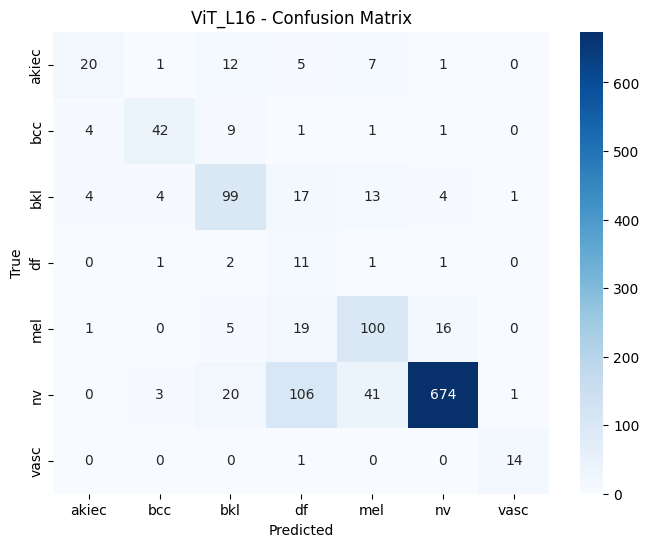

In [16]:
vit_model.load_state_dict(torch.load("/content/vit_stage2_best.pth", map_location=DEVICE))

test_loss, test_acc, test_f1, test_qwk, y_pred, y_true, y_prob = evaluate(vit_model, test_loader)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test macro F1:", test_f1)
print("Test QWK:", test_qwk)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("ViT_L16 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [17]:
tta_transforms = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1), T.ToTensor(), T.Normalize(MEAN, STD)]),
]

class TTADataset(Dataset):
    def __init__(self, df, transforms_list):
        self.df = df.reset_index(drop=True)
        self.transforms_list = transforms_list

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['model_path']).convert('RGB')
        label = int(row['label'])
        imgs = [tr(img) for tr in self.transforms_list]
        return imgs, label

tta_dataset = TTADataset(test_df, tta_transforms)

@torch.no_grad()
def evaluate_tta(model, tta_dataset, batch_size=8):
    model.eval()
    all_probs, all_labels = [], []

    for start in tqdm(range(0, len(tta_dataset), batch_size), desc='TTA'):
        batch_items = [tta_dataset[i] for i in range(start, min(start + batch_size, len(tta_dataset)))]
        labels = torch.tensor([x[1] for x in batch_items]).to(DEVICE)

        probs_sum = None
        for t_idx in range(len(tta_transforms)):
            imgs = torch.stack([x[0][t_idx] for x in batch_items]).to(DEVICE)
            with autocast():
                out = model(imgs)
                probs = F.softmax(out, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs

        probs_avg = probs_sum / len(tta_transforms)
        all_probs.extend(probs_avg.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = np.argmax(all_probs, axis=1)

    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, preds, weights='quadratic')
    return acc, f1, qwk, preds, all_labels

tta_acc, tta_f1, tta_qwk, tta_pred, tta_true = evaluate_tta(vit_model, tta_dataset, batch_size=8)

print("TTA accuracy:", tta_acc)
print("TTA macro F1:", tta_f1)
print("TTA QWK:", tta_qwk)

TTA: 100%|██████████| 158/158 [03:42<00:00,  1.41s/it]

TTA accuracy: 0.7640538400633412
TTA macro F1: 0.6489811530570632
TTA QWK: 0.765717134474709
